# Import Scripts and Load the Merged Data

In [1]:
import os
import sys

PROJECT_ROOT = os.getcwd()

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
from pathlib import Path

OUTPUT_DIR = Path("outputs")
SUMMARY_DIR = OUTPUT_DIR / "summaries"
DIAG_DIR = OUTPUT_DIR / "diagnostics"
FORECAST_DIR = OUTPUT_DIR / "forecasts"
DRAWS_DIR = OUTPUT_DIR / "draws"

for folder in [SUMMARY_DIR, DIAG_DIR, FORECAST_DIR, DRAWS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

In [3]:
# merge the four datasets
from src.data.build_dataset import build_market_dataset

df = build_market_dataset()
df.head()

,date,SPY,QQQ,DIA,IWN
0,2002-01-03,1.127519,3.406775,0.975425,1.156449
1,2002-01-04,0.665375,0.408802,0.857495,0.847332
2,2002-01-07,-0.708118,-1.110050,-0.612907,-1.100651
3,2002-01-08,-0.231511,0.677149,-0.457057,0.803877
4,2002-01-09,-0.818595,-0.920103,-0.557779,-0.389629


In [4]:
df.shape

(6021, 5)

In [5]:
df.describe()

,date,SPY,QQQ,DIA,IWN
count,6021,6021.000000,6021.000000,6021.000000,6021.000000
mean,2014-01-16 08:07:24.843049472,0.039695,0.047040,0.026213,0.033360
min,2002-01-03 00:00:00,-11.588661,-12.759215,-13.841813,-14.064349
25%,2008-01-03 00:00:00,-0.422976,-0.591504,-0.436183,-0.686882
50%,2013-12-24 00:00:00,0.071503,0.114323,0.053446,0.068304
75%,2020-02-24 00:00:00,0.587825,0.760659,0.549566,0.809751
max,2026-02-19 00:00:00,19.985740,11.479906,10.764325,9.062167
std,NaN,1.230961,1.438580,1.146539,1.518730


<Axes: >

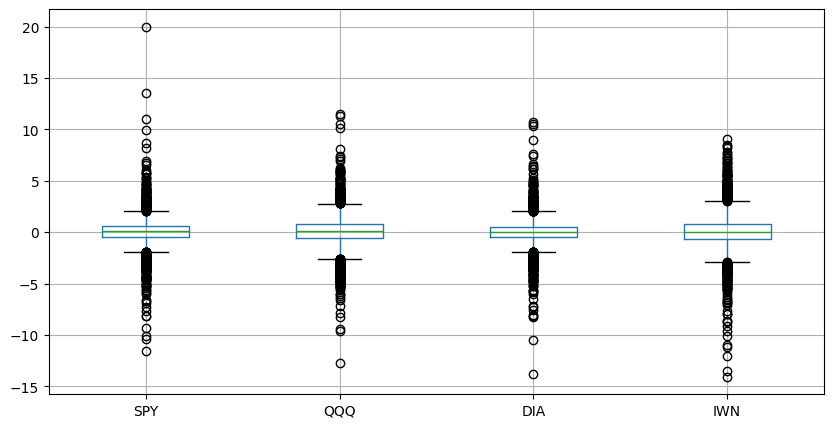

In [6]:
# inspecting tails
df.boxplot(figsize=(10,5))

we can see many assymetric tails and outliers beyond whiskers, which is our motivation to do flexible innovations

# Base VAR Test

In [7]:
from src.models.base_var import BaseVAR

var = BaseVAR(p=2, intercept=True)
design = var.build_design(df)

print("X shape:", design.X.shape)
print("Y shape:", design.Y.shape)
print("Dates shape:", design.dates.shape)
print("First 10 feature names:", design.feature_names[:10])

X shape: (6019, 9)
Y shape: (6019, 4)
Dates shape: (6019,)
First 10 feature names: ['intercept', 'SPY_lag1', 'QQQ_lag1', 'DIA_lag1', 'IWN_lag1', 'SPY_lag2', 'QQQ_lag2', 'DIA_lag2', 'IWN_lag2']


# Gaussian VAR w/ OLS

In [8]:
from src.models.gaussian_var import GaussianVAR

model = GaussianVAR(p=2, intercept=True)
result = model.fit(df)
model.summary()

{'p': 2,
 'intercept': True,
 'n_obs_effective': 6019,
 'n_series': 4,
 'n_features': 9,
 'beta_shape': (4, 9),
 'sigma_shape': (4, 4)}

In [9]:
import pandas as pd
import numpy as np

series_names = ["SPY", "QQQ", "DIA", "IWN"]
feature_names = result.design.feature_names

In [10]:
# beta arrays
beta_df = pd.DataFrame(result.beta, index=series_names, columns=feature_names)
beta_df.to_csv(SUMMARY_DIR / "gaussian_beta.csv")
beta_df

,intercept,SPY_lag1,QQQ_lag1,DIA_lag1,IWN_lag1,SPY_lag2,QQQ_lag2,DIA_lag2,IWN_lag2
SPY,0.043119,-0.102996,0.063858,-0.116494,0.050628,-0.158564,0.037708,0.104615,0.015981
QQQ,0.050834,-0.067360,0.047244,-0.144370,0.037997,-0.069199,-0.013675,0.043241,0.024653
DIA,0.029114,-0.042335,0.051049,-0.168244,0.043563,-0.130236,0.026190,0.090748,0.018301
IWN,0.036153,-0.026747,0.028839,-0.119219,-0.004357,-0.103833,0.012718,0.158045,-0.023015


In [11]:
# error arrays
sigma_df = pd.DataFrame(result.sigma, index=series_names, columns=series_names)
sigma_df.to_csv(SUMMARY_DIR / "gaussian_sigma.csv")
sigma_df

,SPY,QQQ,DIA,IWN
SPY,1.499098,1.552373,1.308057,1.551117
QQQ,1.552373,2.049127,1.361986,1.598239
DIA,1.308057,1.361986,1.296368,1.463149
IWN,1.551117,1.598239,1.463149,2.284474


In [12]:
# residuals DF
resid_df = pd.DataFrame(result.residuals, columns=series_names)
resid_df.insert(0, "date", result.design.dates.values)
resid_df.to_csv(DIAG_DIR / "gaussian_residuals.csv", index=False)

In [13]:
from scipy.stats import kurtosis
resid_df.drop(columns="date").kurtosis()

SPY    22.566209
QQQ     5.637562
DIA    12.693664
IWN     7.510998
dtype: float64

Kurtosis > 3, justifies use of T-Var

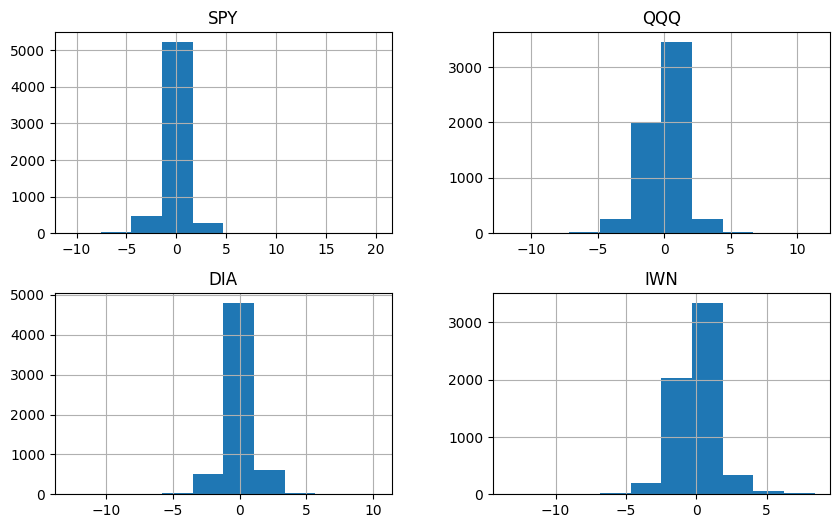

In [14]:
import matplotlib.pyplot as plt

resid_df.drop(columns="date").hist(figsize=(10, 6))
plt.show()

# Student t-VAR

It uses the standard scale-mixture representation:

- $\varepsilon_t \mid \lambda_t \sim \mathcal{N}(0, \Sigma / \lambda_t)$

- $\lambda_t \sim \text{Gamma}(\nu/2,\nu/2)$

and fits the model with a simple Gibbs sampler:

- sample $\beta$ by weighted least squares

- sample $\Sigma$ from residuals
	
- sample latent scales $\lambda_t$


In [15]:
%load_ext autoreload
%autoreload 2

In [16]:
from src.data.build_dataset import build_market_dataset
from src.models.student_t_var import StudentTVAR

df = build_market_dataset()

model_t = StudentTVAR(p=2, intercept=True, nu=8, seed=123)
result_t = model_t.fit(df, n_iter=800, burn=300)

model_t.summary()

{'p': 2,
 'intercept': True,
 'nu': 8.0,
 'n_saved_draws': 500,
 'n_obs_effective': 6019,
 'n_series': 4,
 'n_features': 9,
 'beta_draw_shape': (4, 9),
 'sigma_draw_shape': (4, 4)}

In [17]:
beta_t_mean = model_t.posterior_mean_beta()
print(beta_t_mean)

[[ 0.07678809 -0.03746885  0.02575905 -0.06867602  0.01614879  0.00456455
  -0.00612163  0.0190525  -0.01872983]
 [ 0.09917369  0.01617924 -0.00105543 -0.08571939  0.01461504  0.04461496
  -0.02742605 -0.01353899 -0.01078229]
 [ 0.05712613  0.03440435  0.00788736 -0.12052098  0.0103322   0.01379111
  -0.0058124   0.01322823 -0.0160372 ]
 [ 0.06675527  0.04927198  0.00076607 -0.08950308 -0.02165132  0.07299449
  -0.02286211  0.02276491 -0.05754926]]


In [18]:
sigma_t_mean = model_t.posterior_mean_sigma()
print(sigma_t_mean)

[[0.7166144  0.81562496 0.64842841 0.8035225 ]
 [0.81562496 1.13601418 0.70169771 0.87028289]
 [0.64842841 0.70169771 0.64765873 0.74511776]
 [0.8035225  0.87028289 0.74511776 1.2621124 ]]


In [19]:
beta_t_df = pd.DataFrame(beta_t_mean, index=series_names, columns=feature_names)
sigma_t_df = pd.DataFrame(sigma_t_mean, index=series_names, columns=series_names)

beta_t_df.to_csv(SUMMARY_DIR / "student_t_beta_mean.csv")
sigma_t_df.to_csv(SUMMARY_DIR / "student_t_sigma_mean.csv")

In [20]:
lam_last = result_t.lambda_draws[-1]

print("lambda min:", lam_last.min())
print("lambda max:", lam_last.max())
print("lambda mean:", lam_last.mean())

lam_df = pd.DataFrame({
    "date": result_t.design.dates.values,
    "lambda": lam_last,
})
lam_df.to_csv(DIAG_DIR / "student_t_lambda_last.csv", index=False)

lambda min: 0.000835401276552475
lambda max: 4.555393402270686
lambda mean: 1.0021429127961687


In [21]:
resid_t_df = pd.DataFrame(result_t.residuals_last, columns=series_names)
resid_t_df.insert(0, "date", result_t.design.dates.values)
resid_t_df.to_csv(DIAG_DIR / "student_t_residuals_last.csv", index=False)

In [22]:
resid_df.drop(columns="date").kurtosis()

SPY    22.566209
QQQ     5.637562
DIA    12.693664
IWN     7.510998
dtype: float64

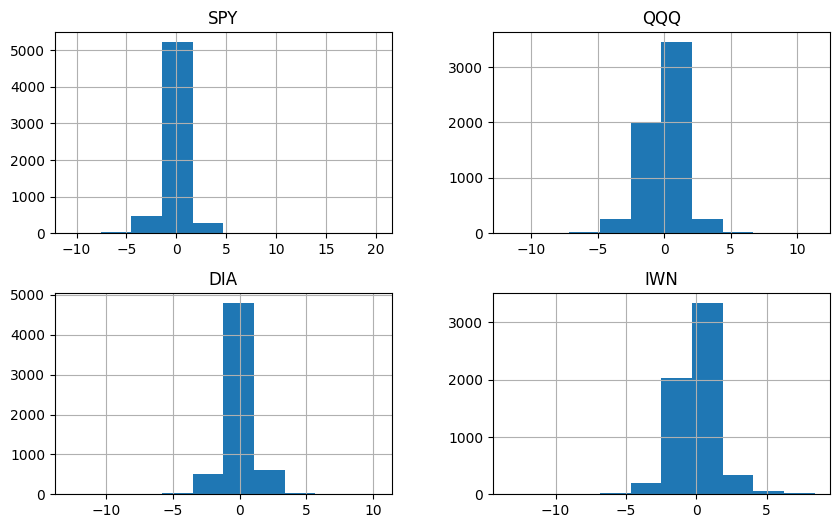

In [23]:
import matplotlib.pyplot as plt

resid_df.drop(columns="date").hist(figsize=(10,6))
plt.show()

In [24]:
print(len(result_t.beta_draws))
print(len(result_t.sigma_draws))

500
500


In [25]:
import numpy as np

np.mean([np.linalg.norm(b) for b in result_t.beta_draws])

np.float64(0.29011863434277185)

# Mixture VAR

This is the model where the innovation distribution is:

$$
\varepsilon_t \sim \sum_{k=1}^K \pi_k \mathcal{N}(0,\Sigma_k)
$$

with latent regime indicator:

$$
z_t \in {1,\dots,K}
$$

So each time point belongs to a latent shock regime, and each regime has its own covariance structure.

In [26]:
from src.data.build_dataset import build_market_dataset
from src.models.mixture_var import MixtureVAR

df = build_market_dataset()

mix_model = MixtureVAR(
    p=2,
    intercept=True,
    n_components=2,
    seed=123
)

mix_result = mix_model.fit(df, n_iter=800, burn=300)
mix_model.summary()

{'p': 2,
 'intercept': True,
 'n_components': 2,
 'n_saved_draws': 500,
 'n_obs_effective': 6019,
 'n_series': 4,
 'n_features': 9,
 'beta_draw_shape': (4, 9),
 'sigma_draw_shape': (2, 4, 4),
 'pi_draw_shape': (2,),
 'z_draw_shape': (6019,)}

In [27]:
beta_mix_mean = mix_model.posterior_mean_beta()
beta_mix_df = pd.DataFrame(beta_mix_mean, index=series_names, columns=feature_names)
beta_mix_df.to_csv(SUMMARY_DIR / "mixture_beta_mean.csv")

In [28]:
pi_mix_mean = mix_model.posterior_mean_pi()
pi_mix_df = pd.DataFrame({
    "component": np.arange(len(pi_mix_mean)),
    "posterior_mean_pi": pi_mix_mean
})
pi_mix_df.to_csv(SUMMARY_DIR / "mixture_pi_mean.csv", index=False)
pi_mix_df

,component,posterior_mean_pi
0,0,0.881318
1,1,0.118682


In [29]:
sigma_mix_mean = mix_model.posterior_mean_sigma()

for k in range(sigma_mix_mean.shape[0]):
    sigma_k_df = pd.DataFrame(
        sigma_mix_mean[k],
        index=series_names,
        columns=series_names,
    )
    sigma_k_df.to_csv(SUMMARY_DIR / f"mixture_sigma_component_{k}.csv")

In [30]:
# regime assignments
z_last = mix_result.z_draws[-1]
z_df = pd.DataFrame({
    "date": mix_result.design.dates.values,
    "regime": z_last,
})
z_df.to_csv(DIAG_DIR / "mixture_regime_last.csv", index=False)

In [31]:
import pandas as pd

regime_df = pd.DataFrame({
    "date": mix_result.design.dates,
    "z": z_last
})

regime_df.head()

,date,z
0,2002-01-07,0
1,2002-01-08,0
2,2002-01-09,0
3,2002-01-10,0
4,2002-01-11,0


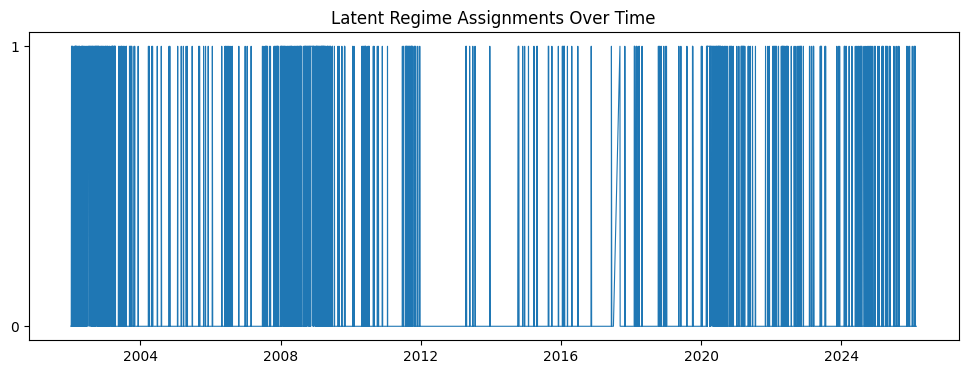

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(regime_df["date"], regime_df["z"], lw=0.8)
plt.title("Latent Regime Assignments Over Time")
plt.yticks([0, 1])
plt.show()

In [33]:
# one step predictive mean
Y = df.drop(columns="date").to_numpy()
last_obs = Y[-2:, :]

mix_model.forecast_one_step_mean(last_obs)

array([0.11920777, 0.1424151 , 0.12215547, 0.1158807 ])

In [34]:
# simulate the PPD
mix_sims = mix_model.simulate_one_step(last_obs, n_sim=2000)
mix_sims.shape

(2000, 4)

In [35]:
sigma_mix = mix_model.posterior_mean_sigma()

print("Regime 0 covariance:")
print(sigma_mix[0])

print("\nRegime 1 covariance:")
print(sigma_mix[1])

Regime 0 covariance:
[[0.6661755  0.77544429 0.59936414 0.76020708]
 [0.77544429 1.09934026 0.65765489 0.84669828]
 [0.59936414 0.65765489 0.60087667 0.69857328]
 [0.76020708 0.84669828 0.69857328 1.22409144]]

Regime 1 covariance:
[[ 7.75286756  7.4113802   6.63995196  7.51353837]
 [ 7.4113802   9.24004047  6.686682    7.29903451]
 [ 6.63995196  6.686682    6.53457773  7.23591869]
 [ 7.51353837  7.29903451  7.23591869 10.29756084]]


We can see from this that covariance explodes in response to market stress, which is consistent with econometrics

In [36]:
regime_df["z"].value_counts(normalize=True)
regime_df[(regime_df["date"] > "2008-01-01") & (regime_df["date"] < "2009-12-31")]

,date,z
1502,2008-01-02,1
1503,2008-01-03,0
1504,2008-01-04,1
1505,2008-01-07,0
1506,2008-01-08,0
...,...,...
2001,2009-12-23,0
2002,2009-12-24,0
2003,2009-12-28,0
2004,2009-12-29,0


In [37]:
regime_df[(regime_df["date"] > "2020-02-01") & (regime_df["date"] < "2020-06-01")]

,date,z
4499,2020-02-03,0
4500,2020-02-04,0
4501,2020-02-05,0
4502,2020-02-06,0
4503,2020-02-07,0
...,...,...
4576,2020-05-22,0
4577,2020-05-26,1
4578,2020-05-27,1
4579,2020-05-28,0


# Stoch. Vol. VAR

Build a VAR with time-varying innovation variance:

$$
y_t = Bx_t + \varepsilon_t,\qquad \varepsilon_t \sim \mathcal N(0,\Sigma_t)
$$

To keep this tractable, we’ll use a diagonal stochastic volatility version first:

$$
\Sigma_t = \mathrm{diag}(\exp(h_{t,1}), \dots, \exp(h_{t,d}))
$$

with latent log-volatility states following AR(1)-style dynamics:

$$
h_{t,j} = \mu_j + \phi_j(h_{t-1,j}-\mu_j) + \eta_{t,j}, \qquad \eta_{t,j}\sim \mathcal N(0,\sigma_{h,j}^2)
$$


In [38]:
from src.data.build_dataset import build_market_dataset
from src.models.sv_var import SVVAR

df = build_market_dataset()

sv_model = SVVAR(
    p=2,
    intercept=True,
    phi=0.98,
    sigma_h=0.15,
    seed=123,
)

sv_result = sv_model.fit(df, n_iter=800, burn=300)
sv_model.summary()

{'p': 2,
 'intercept': True,
 'phi': 0.98,
 'sigma_h': 0.15,
 'n_saved_draws': 500,
 'n_obs_effective': 6019,
 'n_series': 4,
 'n_features': 9,
 'beta_draw_shape': (4, 9),
 'h_draw_shape': (6019, 4)}

In [39]:
beta_sv_mean = sv_model.posterior_mean_beta()
beta_sv_df = pd.DataFrame(beta_sv_mean, index=series_names, columns=feature_names)
beta_sv_df.to_csv(SUMMARY_DIR / "sv_beta_mean.csv")

In [40]:
h_sv_mean = sv_model.posterior_mean_h()
h_sv_df = pd.DataFrame(h_sv_mean, columns=[f"{name}_logvol" for name in series_names])
h_sv_df.insert(0, "date", sv_result.design.dates.values)
h_sv_df.to_csv(DIAG_DIR / "sv_logvol_mean.csv", index=False)

In [41]:
vol_sv_df = pd.DataFrame(np.exp(h_sv_mean / 2), columns=[f"{name}_vol" for name in series_names])
vol_sv_df.insert(0, "date", sv_result.design.dates.values)
vol_sv_df.to_csv(DIAG_DIR / "sv_vol_mean.csv", index=False)

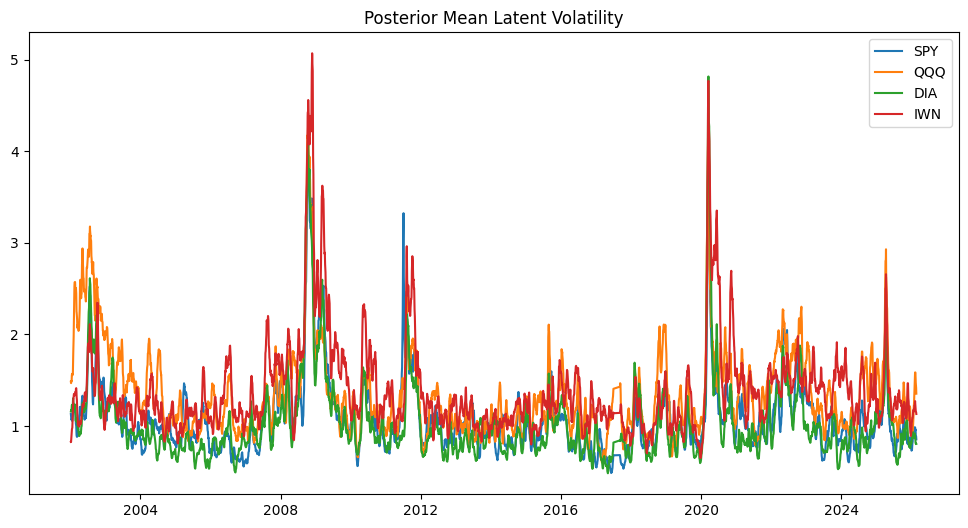

In [42]:
# latent volatility over time
import matplotlib.pyplot as plt
import numpy as np

dates = sv_result.design.dates

plt.figure(figsize=(12, 6))
for j, name in enumerate(["SPY", "QQQ", "DIA", "IWN"]):
    plt.plot(dates, np.exp(h_sv_mean[:, j] / 2), label=name)

plt.title("Posterior Mean Latent Volatility")
plt.legend()
plt.show()

In [43]:
# one step pred mean
Y = df.drop(columns="date").to_numpy()
last_obs = Y[-2:, :]

sv_model.forecast_one_step_mean(last_obs)

array([0.10253626, 0.13000449, 0.11731912, 0.1008434 ])

In [44]:
# PPD draws
sv_sims = sv_model.simulate_one_step(last_obs, n_sim=2000)
sv_sims.shape

(2000, 4)

# Evaluation and Metrics

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.evaluation.metrics import (
    log_predictive_score_univariate,
    var_from_draws,
    es_from_draws,
    predictive_summary,
    hit_var,
)

from src.evaluation.diagnostics import (
    effective_sample_size,
    split_rhat,
    extract_scalar_chain_from_beta_draws,
    extract_scalar_chain_from_sigma_draws,
)

from src.evaluation.rolling_forecast import (
    rolling_forecast_univariate_target,
    summarize_rolling_results,
    compare_models_rolling,
)

In [46]:
# Set up the last observed lags for one-step predictive testing
cols = [c for c in df.columns if c != "date"]
Y_np = df[cols].to_numpy(dtype=float)

p = 2
last_obs = Y_np[-p:, :]
last_true = Y_np[-1, :]   # most recent realized return vector
cols

['SPY', 'QQQ', 'DIA', 'IWN']

In [47]:
# simulate one-step draws from each model
n_sim = 2000

g_sims = model.simulate_one_step(last_obs, n_sim=n_sim)
t_sims = model_t.simulate_one_step(last_obs, n_sim=n_sim)
mix_sims = mix_model.simulate_one_step(last_obs, n_sim=n_sim)
sv_sims = sv_model.simulate_one_step(last_obs, n_sim=n_sim)

print(g_sims.shape, t_sims.shape, mix_sims.shape, sv_sims.shape)

(2000, 4) (2000, 4) (2000, 4) (2000, 4)


## In-Sample (Fitted Model) Metrics

In [48]:
# Test LPS, VaR, ES for one target series (SPY)
target_col = "SPY"
target_idx = cols.index(target_col)
y_true = last_true[target_idx]

g_draws = g_sims[:, target_idx]
t_draws = t_sims[:, target_idx]
mix_draws = mix_sims[:, target_idx]
sv_draws = sv_sims[:, target_idx]

alpha = 0.05

metrics_table = pd.DataFrame({
    "model": ["gaussian", "student_t", "mixture", "sv"],
    "lps": [
        log_predictive_score_univariate(y_true, g_draws),
        log_predictive_score_univariate(y_true, t_draws),
        log_predictive_score_univariate(y_true, mix_draws),
        log_predictive_score_univariate(y_true, sv_draws),
    ],
    "VaR_5%": [
        var_from_draws(g_draws, alpha),
        var_from_draws(t_draws, alpha),
        var_from_draws(mix_draws, alpha),
        var_from_draws(sv_draws, alpha),
    ],
    "ES_5%": [
        es_from_draws(g_draws, alpha),
        es_from_draws(t_draws, alpha),
        es_from_draws(mix_draws, alpha),
        es_from_draws(sv_draws, alpha),
    ],
})

metrics_table

,model,lps,VaR_5%,ES_5%
0,gaussian,-1.185740,-1.934581,-2.373128
1,student_t,-0.906331,-1.491362,-2.007723
2,mixture,-0.947320,-1.490658,-2.610159
3,sv,-0.812582,-1.352377,-1.751613


In [49]:
# VAR hit indicator
metrics_table["VaR_hit"] = [
    hit_var(y_true, metrics_table.loc[0, "VaR_5%"]),
    hit_var(y_true, metrics_table.loc[1, "VaR_5%"]),
    hit_var(y_true, metrics_table.loc[2, "VaR_5%"]),
    hit_var(y_true, metrics_table.loc[3, "VaR_5%"]),
]

metrics_table

,model,lps,VaR_5%,ES_5%,VaR_hit
0,gaussian,-1.185740,-1.934581,-2.373128,0
1,student_t,-0.906331,-1.491362,-2.007723,0
2,mixture,-0.947320,-1.490658,-2.610159,0
3,sv,-0.812582,-1.352377,-1.751613,0


In [50]:
# Quick predictive summary
for name, draws in {
    "gaussian": g_draws,
    "student_t": t_draws,
    "mixture": mix_draws,
    "sv": sv_draws,
}.items():
    print(name, predictive_summary(draws, alpha=0.05))

gaussian {'mean': 0.13442947861813018, 'std': 1.2207592675457302, 'var_alpha': -1.934581172849909, 'es_alpha': -2.373128212791646}
student_t {'mean': 0.12102641365340208, 'std': 0.9742933580672559, 'var_alpha': -1.491362038027162, 'es_alpha': -2.0077229700516734}
mixture {'mean': 0.14370743592694943, 'std': 1.1888310650207639, 'var_alpha': -1.4906578208703385, 'es_alpha': -2.6101588168659196}
sv {'mean': 0.07674197275419675, 'std': 0.865903691625942, 'var_alpha': -1.3523766569477371, 'es_alpha': -1.7516129977124735}


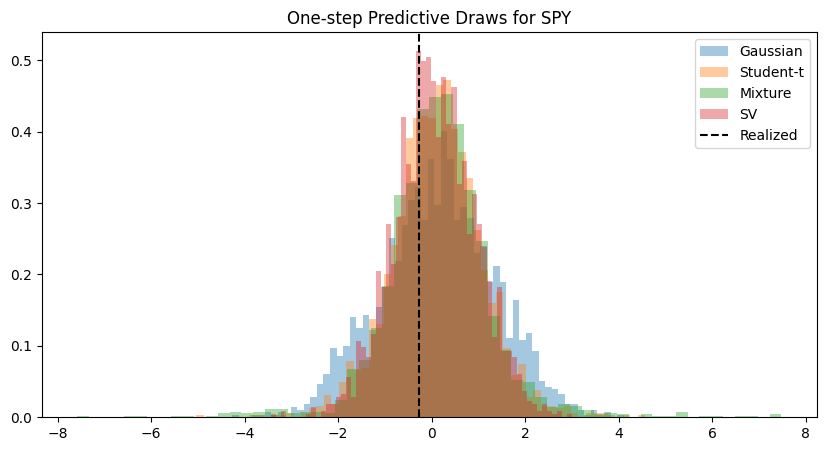

In [51]:
plt.figure(figsize=(10, 5))
plt.hist(g_draws, bins=60, alpha=0.4, label="Gaussian", density=True)
plt.hist(t_draws, bins=60, alpha=0.4, label="Student-t", density=True)
plt.hist(mix_draws, bins=60, alpha=0.4, label="Mixture", density=True)
plt.hist(sv_draws, bins=60, alpha=0.4, label="SV", density=True)
plt.axvline(y_true, color="black", linestyle="--", label="Realized")
plt.title(f"One-step Predictive Draws for {target_col}")
plt.legend()
plt.show()

In [52]:
# Student t ESS for beta
beta_chain_t = extract_scalar_chain_from_beta_draws(
    result_t.beta_draws,
    equation_idx=0,
    coef_idx=1,
)

ess_beta_t = effective_sample_size(beta_chain_t)
ess_beta_t

229.62415081714823

In [53]:
# Student t ESS for sigma
sigma_chain_t = extract_scalar_chain_from_sigma_draws(
    result_t.sigma_draws,
    i=0,
    j=0,
)

ess_sigma_t = effective_sample_size(sigma_chain_t)
ess_sigma_t

138.4023632358292

In [54]:
# Mixture Beta ESS
beta_chain_mix = extract_scalar_chain_from_beta_draws(
    mix_result.beta_draws,
    equation_idx=0,
    coef_idx=1,
)

ess_beta_mix = effective_sample_size(beta_chain_mix)
ess_beta_mix

393.3679006140764

In [55]:
# Mixture Neutral Regime Beta ESS
sigma_chain_mix = extract_scalar_chain_from_sigma_draws(
    mix_result.sigma_draws,
    i=0,
    j=0,
    component=0,
)

ess_sigma_mix = effective_sample_size(sigma_chain_mix)
ess_sigma_mix

64.15850226189133

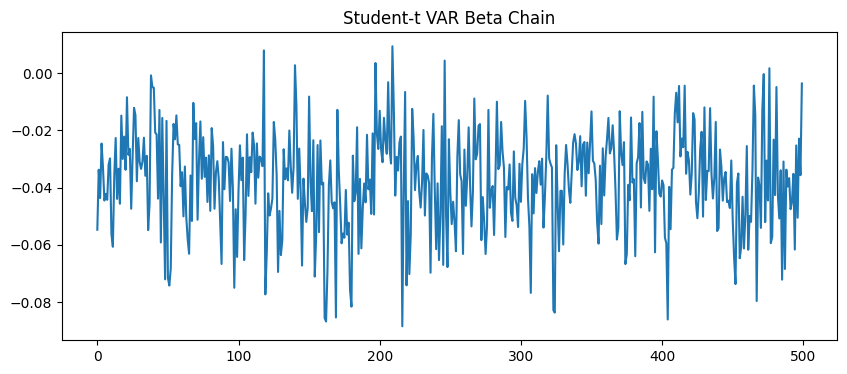

In [56]:
# Student t beta chain
plt.figure(figsize=(10, 4))
plt.plot(beta_chain_t)
plt.title("Student-t VAR Beta Chain")
plt.show()

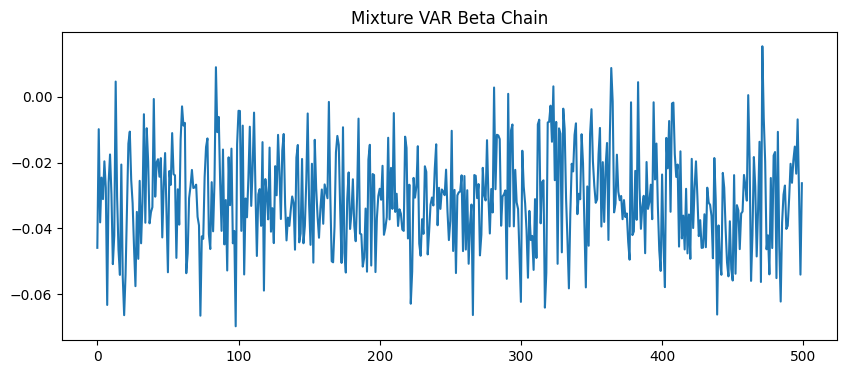

In [57]:
# Mixture beta chain
plt.figure(figsize=(10, 4))
plt.plot(beta_chain_mix)
plt.title("Mixture VAR Beta Chain")
plt.show()

In [58]:
# Rhat
# run a second Student-t model:
model_t2 = StudentTVAR(p=2, intercept=True, nu=8, seed=456)
result_t2 = model_t2.fit(df, n_iter=800, burn=300)

chain1 = extract_scalar_chain_from_beta_draws(result_t.beta_draws, equation_idx=0, coef_idx=1)
chain2 = extract_scalar_chain_from_beta_draws(result_t2.beta_draws, equation_idx=0, coef_idx=1)

rhat_beta_t = split_rhat(np.vstack([chain1, chain2]))
rhat_beta_t

0.998693335888562

In [59]:
from src.evaluation.diagnostics import (
    effective_sample_size,
    extract_scalar_chain_from_beta_draws,
    extract_scalar_chain_from_sigma_draws,
)

diag_rows = []

# Student-t beta chain
chain = extract_scalar_chain_from_beta_draws(result_t.beta_draws, equation_idx=0, coef_idx=1)
diag_rows.append({
    "model": "student_t",
    "parameter": "beta_SPY_eq_SPY_lag1",
    "ESS": effective_sample_size(chain),
})

# Student-t sigma chain
chain = extract_scalar_chain_from_sigma_draws(result_t.sigma_draws, i=0, j=0)
diag_rows.append({
    "model": "student_t",
    "parameter": "sigma_SPY_SPY",
    "ESS": effective_sample_size(chain),
})

# Mixture beta chain
chain = extract_scalar_chain_from_beta_draws(mix_result.beta_draws, equation_idx=0, coef_idx=1)
diag_rows.append({
    "model": "mixture",
    "parameter": "beta_SPY_eq_SPY_lag1",
    "ESS": effective_sample_size(chain),
})

# Mixture sigma chain, component 0
chain = extract_scalar_chain_from_sigma_draws(mix_result.sigma_draws, i=0, j=0, component=0)
diag_rows.append({
    "model": "mixture",
    "parameter": "sigma0_SPY_SPY",
    "ESS": effective_sample_size(chain),
})

diag_df = pd.DataFrame(diag_rows)
diag_df.to_csv(DIAG_DIR / "ess_summary.csv", index=False)
diag_df

,model,parameter,ESS
0,student_t,beta_SPY_eq_SPY_lag1,229.624151
1,student_t,sigma_SPY_SPY,138.402363
2,mixture,beta_SPY_eq_SPY_lag1,393.367901
3,mixture,sigma0_SPY_SPY,64.158502


## Out of Sample (Rolling Forecast) Metrics

In [60]:
from src.models.gaussian_var import GaussianVAR
from src.models.student_t_var import StudentTVAR
from src.models.mixture_var import MixtureVAR
from src.models.sv_var import SVVAR

# model specs
model_specs = {
    "gaussian": (GaussianVAR, {"p": 2, "intercept": True}),
    "student_t": (StudentTVAR, {"p": 2, "intercept": True, "nu": 8, "seed": 123}),
    #"mixture": (MixtureVAR, {"p": 2, "intercept": True, "n_components": 2, "seed": 123}), # (these two are slow, we can debug this later)
    #"sv": (SVVAR, {"p": 2, "intercept": True, "phi": 0.98, "sigma_h": 0.15, "seed": 123}),
}

# comparison for SPY (scale window size to 1000 and sim=500 later), we just want to know if it works
all_results, summary_df = compare_models_rolling(
    data=df,
    model_specs=model_specs,
    target_col="SPY",
    window_size=200,
    p=2,
    n_sim=50,
    alpha=0.05,
    step_size=50,
    verbose=True,
)

summary_df


Running model: gaussian
[GaussianVAR] step 1/117
[GaussianVAR] step 11/117
[GaussianVAR] step 21/117
[GaussianVAR] step 31/117
[GaussianVAR] step 41/117
[GaussianVAR] step 51/117
[GaussianVAR] step 61/117
[GaussianVAR] step 71/117
[GaussianVAR] step 81/117
[GaussianVAR] step 91/117
[GaussianVAR] step 101/117
[GaussianVAR] step 111/117

Running model: student_t
[StudentTVAR] step 1/117
[StudentTVAR] step 11/117
[StudentTVAR] step 21/117
[StudentTVAR] step 31/117
[StudentTVAR] step 41/117
[StudentTVAR] step 51/117
[StudentTVAR] step 61/117
[StudentTVAR] step 71/117
[StudentTVAR] step 81/117
[StudentTVAR] step 91/117
[StudentTVAR] step 101/117
[StudentTVAR] step 111/117


,n_forecasts,mean_lps,total_lps,avg_pred_std,var_hit_rate,expected_var_rate,mean_es,model
0,117,-3.162720,-370.038226,1.021464,0.145299,0.05,-1.680206,student_t
1,117,-3.383977,-395.925286,1.090869,0.102564,0.05,-2.096005,gaussian


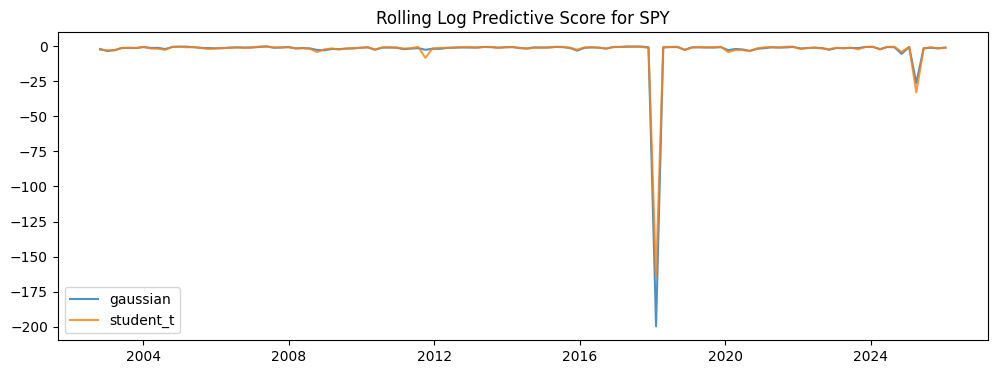

In [61]:
# Plot rolling LPS
plt.figure(figsize=(12, 4))
for name, res in all_results.items():
    plt.plot(res["date"], res["lps"], label=name, alpha=0.8)
plt.legend()
plt.title("Rolling Log Predictive Score for SPY")
plt.show()

In [62]:
# compare hit rate (should be near 5%)
summary_df[["model", "var_hit_rate", "expected_var_rate", "mean_lps", "mean_es"]]

,model,var_hit_rate,expected_var_rate,mean_lps,mean_es
0,student_t,0.145299,0.05,-3.162720,-1.680206
1,gaussian,0.102564,0.05,-3.383977,-2.096005


In [63]:
for name, res in all_results.items():
    res.to_csv(FORECAST_DIR / f"rolling_{name}_SPY.csv", index=False)

summary_df.to_csv(FORECAST_DIR / "rolling_summary_SPY.csv", index=False)

In [64]:
pd.DataFrame({"draw": g_draws}).to_csv(DRAWS_DIR / "gaussian_spy_draws.csv", index=False)
pd.DataFrame({"draw": t_draws}).to_csv(DRAWS_DIR / "student_t_spy_draws.csv", index=False)
pd.DataFrame({"draw": mix_draws}).to_csv(DRAWS_DIR / "mixture_spy_draws.csv", index=False)
pd.DataFrame({"draw": sv_draws}).to_csv(DRAWS_DIR / "sv_spy_draws.csv", index=False)

In [65]:
# TODO: Run evaluation on all models, starting with n_sim=200 and window size 500
# TODO: ^ scale later

# Figures

In [66]:
from datetime import datetime
RUN_TS = datetime.now().strftime("%Y%m%d_%H%M%S")

FIG_ROOT = Path("outputs") / "figures" / RUN_TS
COMMON_FIG = FIG_ROOT / "common"
GAUSS_FIG = FIG_ROOT / "gaussian"
T_FIG = FIG_ROOT / "student_t"
MIX_FIG = FIG_ROOT / "gaussian_mixture"
SV_FIG = FIG_ROOT / "sv"

for folder in [COMMON_FIG, GAUSS_FIG, T_FIG, MIX_FIG, SV_FIG]:
    folder.mkdir(parents=True, exist_ok=True)

SERIES = ["SPY", "QQQ", "DIA", "IWN"]

def savefig(name: str, folder: Path, dpi: int = 200):
    path = folder / f"{name}_{RUN_TS}.png"
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")

Saved: outputs/figures/20260319_160726/common/log_return_timeseries_20260319_160726.png


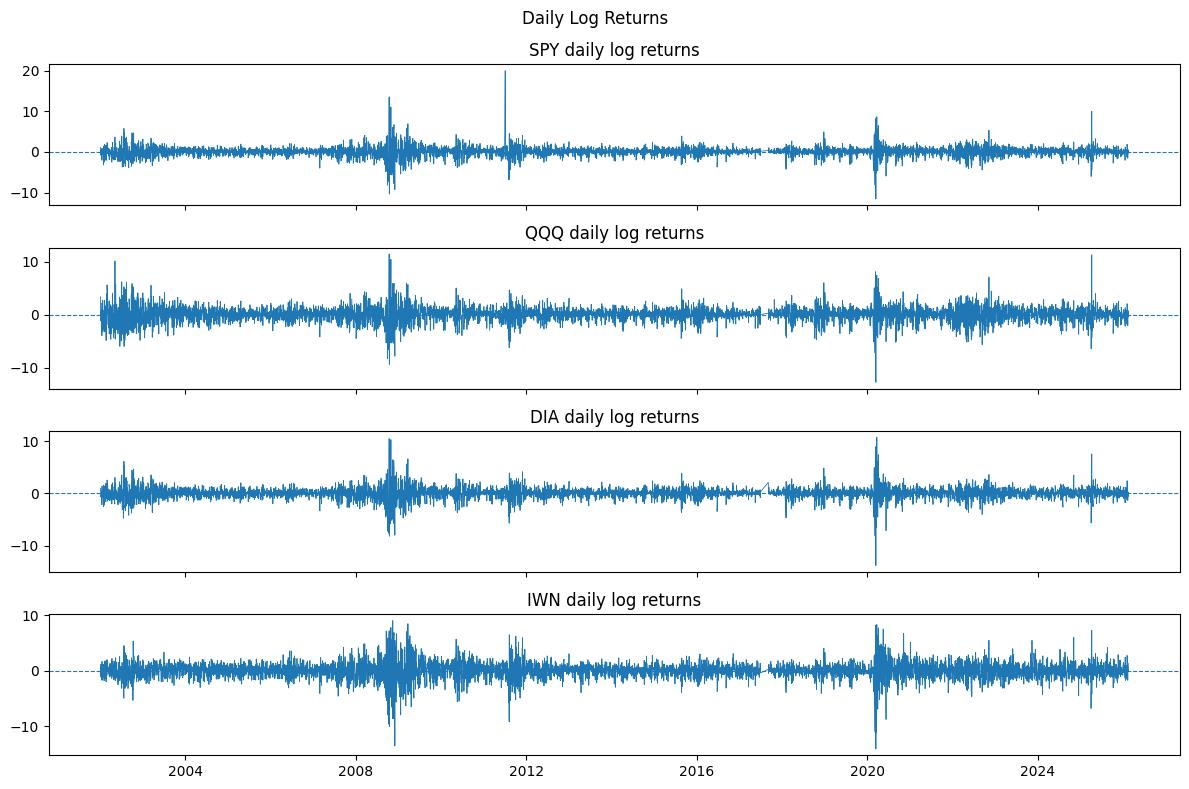

In [67]:
fig, axes = plt.subplots(len(SERIES), 1, figsize=(12, 8), sharex=True)

for i, s in enumerate(SERIES):
    axes[i].plot(df["date"], df[s], linewidth=0.6)
    axes[i].set_title(f"{s} daily log returns")
    axes[i].axhline(0, linestyle="--", linewidth=0.8)

plt.suptitle("Daily Log Returns")
plt.tight_layout()
savefig("log_return_timeseries", COMMON_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/common/rolling_volatility_30d_20260319_160726.png


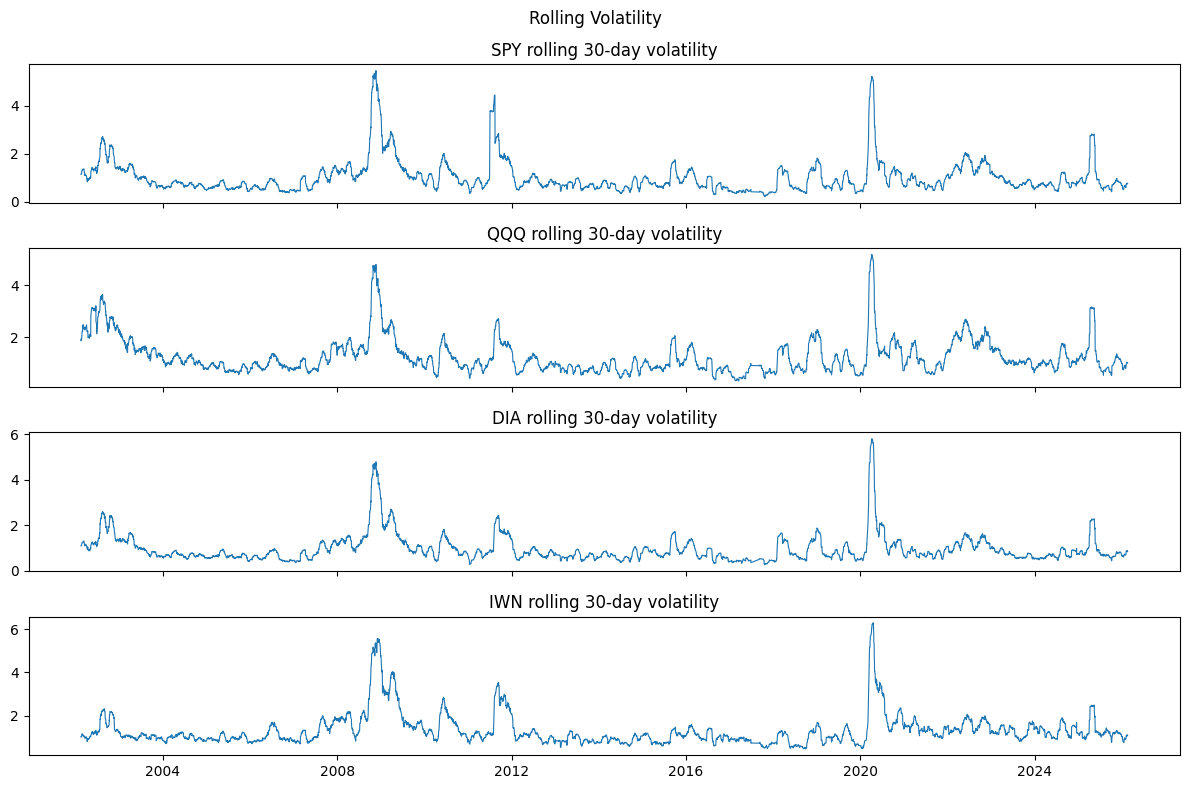

In [68]:
window = 30
fig, axes = plt.subplots(len(SERIES), 1, figsize=(12, 8), sharex=True)

for i, s in enumerate(SERIES):
    rolling_vol = df[s].rolling(window).std()
    axes[i].plot(df["date"], rolling_vol, linewidth=0.8)
    axes[i].set_title(f"{s} rolling {window}-day volatility")

plt.suptitle("Rolling Volatility")
plt.tight_layout()
savefig("rolling_volatility_30d", COMMON_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/common/return_correlation_heatmap_20260319_160726.png


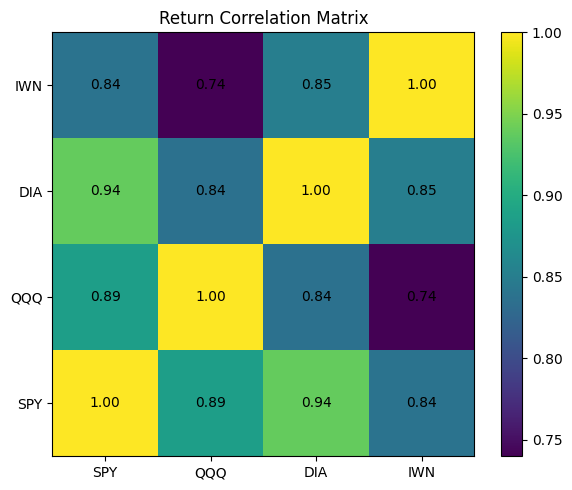

In [69]:
corr = df[SERIES].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, aspect="auto", origin="lower")
ax.set_xticks(range(len(SERIES)))
ax.set_xticklabels(SERIES)
ax.set_yticks(range(len(SERIES)))
ax.set_yticklabels(SERIES)
ax.set_title("Return Correlation Matrix")

for i in range(len(SERIES)):
    for j in range(len(SERIES)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
savefig("return_correlation_heatmap", COMMON_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/common/raw_return_histograms_20260319_160726.png


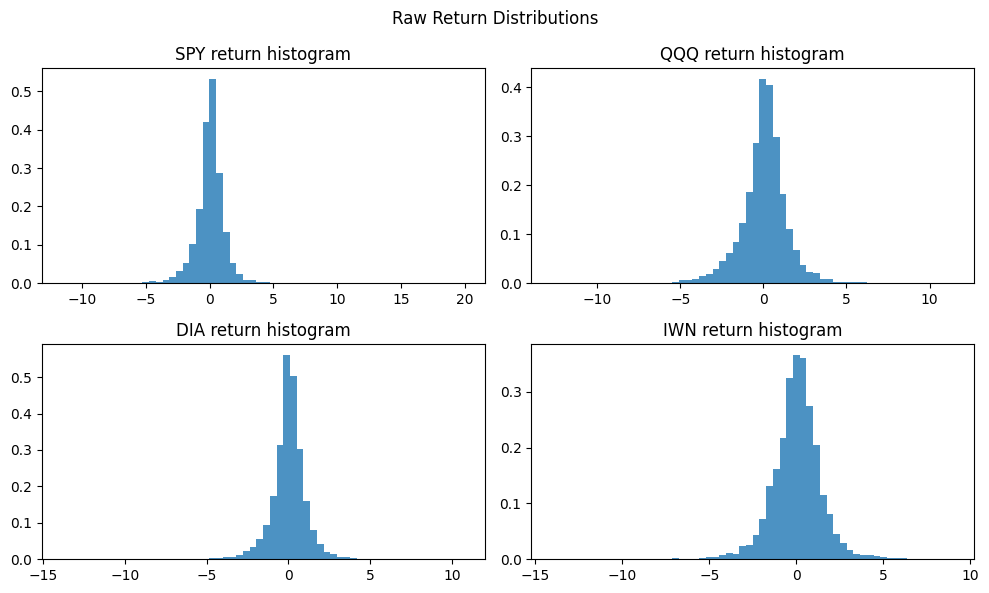

In [70]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()

for i, s in enumerate(SERIES):
    axes[i].hist(df[s], bins=60, density=True, alpha=0.8)
    axes[i].set_title(f"{s} return histogram")

plt.suptitle("Raw Return Distributions")
plt.tight_layout()
savefig("raw_return_histograms", COMMON_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/gaussian/gaussian_residual_histograms_20260319_160726.png


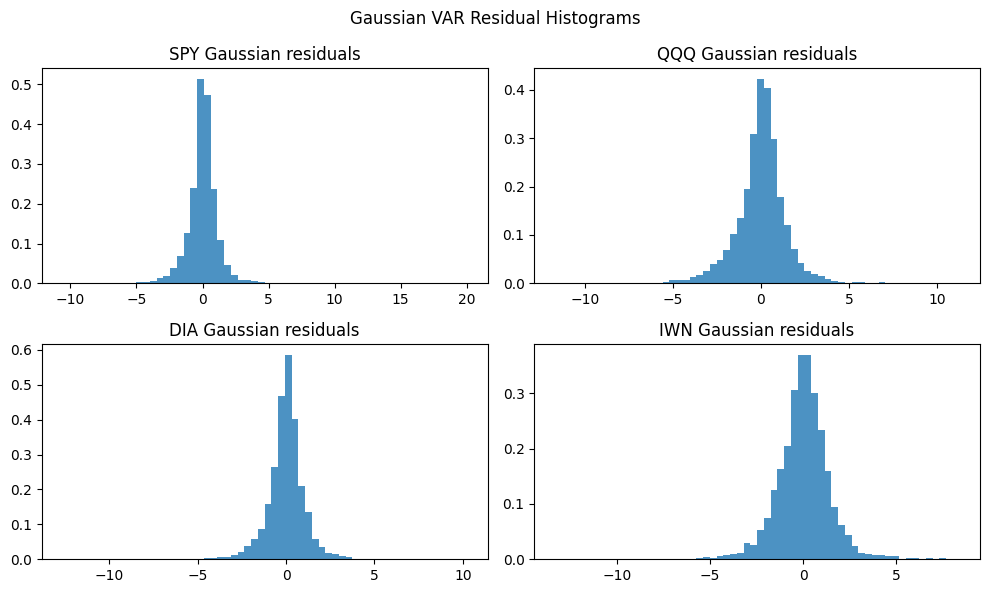

In [71]:
gauss_resid_df = pd.DataFrame(result.residuals, columns=SERIES)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()

for i, s in enumerate(SERIES):
    axes[i].hist(gauss_resid_df[s], bins=60, density=True, alpha=0.8)
    axes[i].set_title(f"{s} Gaussian residuals")

plt.suptitle("Gaussian VAR Residual Histograms")
plt.tight_layout()
savefig("gaussian_residual_histograms", GAUSS_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/gaussian/gaussian_residual_timeseries_20260319_160726.png


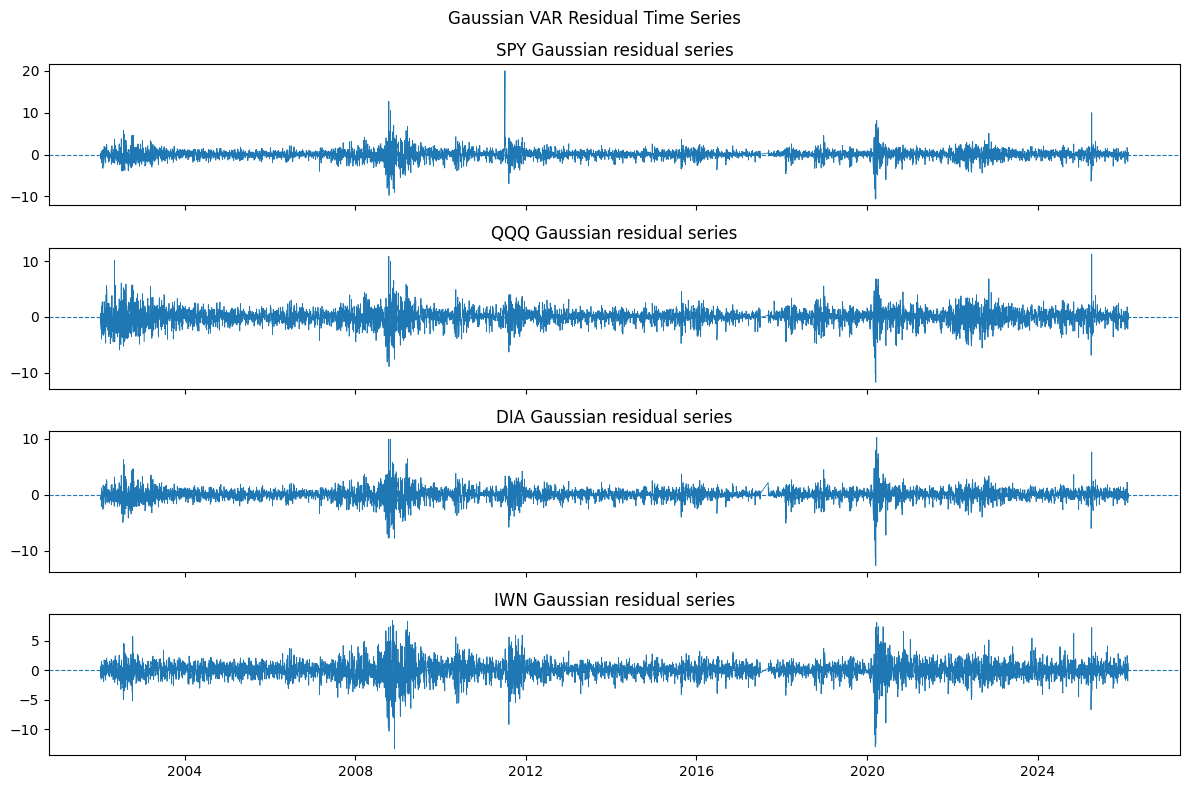

In [72]:
fig, axes = plt.subplots(len(SERIES), 1, figsize=(12, 8), sharex=True)

for i, s in enumerate(SERIES):
    axes[i].plot(result.design.dates, gauss_resid_df[s], linewidth=0.6)
    axes[i].axhline(0, linestyle="--", linewidth=0.8)
    axes[i].set_title(f"{s} Gaussian residual series")

plt.suptitle("Gaussian VAR Residual Time Series")
plt.tight_layout()
savefig("gaussian_residual_timeseries", GAUSS_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/gaussian/gaussian_correlation_heatmap_20260319_160726.png


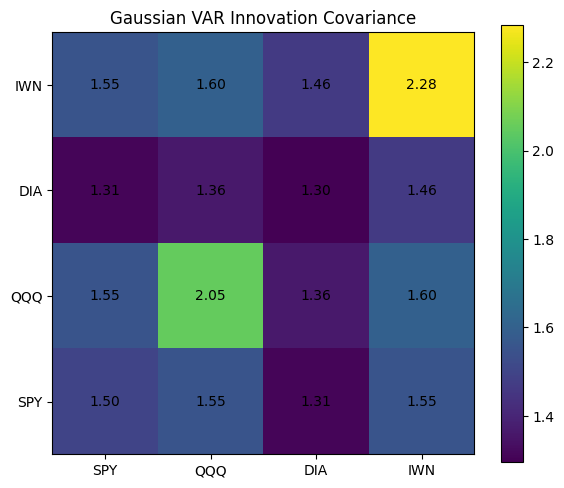

In [76]:
gauss_sigma_df = pd.DataFrame(result.sigma, index=SERIES, columns=SERIES)
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(sigma_df, aspect="equal", origin="lower")

ax.set_xticks(range(len(SERIES)))
ax.set_xticklabels(SERIES)

ax.set_yticks(range(len(SERIES)))
ax.set_yticklabels(SERIES)

ax.set_title("Gaussian VAR Innovation Covariance")

# annotate correctly
for i in range(len(SERIES)):
    for j in range(len(SERIES)):
        ax.text(j, i, f"{sigma_df.iloc[i, j]:.2f}",
                ha="center", va="center", color="black")

plt.colorbar(im, ax=ax)
plt.tight_layout()
savefig("gaussian_correlation_heatmap", GAUSS_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/student_t/student_t_lambda_timeseries_20260319_160726.png


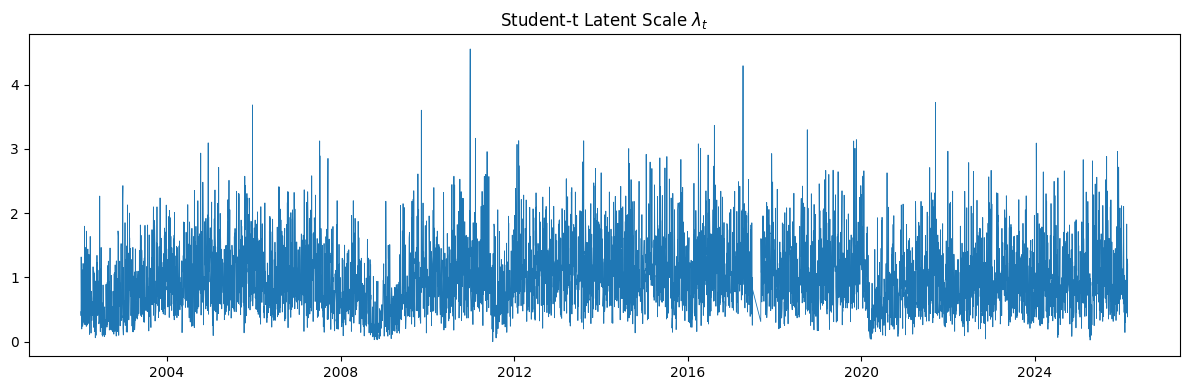

In [77]:
lam_last = result_t.lambda_draws[-1]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(result_t.design.dates, lam_last, linewidth=0.6)
ax.set_title("Student-t Latent Scale $\\lambda_t$")
plt.tight_layout()
savefig("student_t_lambda_timeseries", T_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/student_t/student_t_lambda_histogram_20260319_160726.png


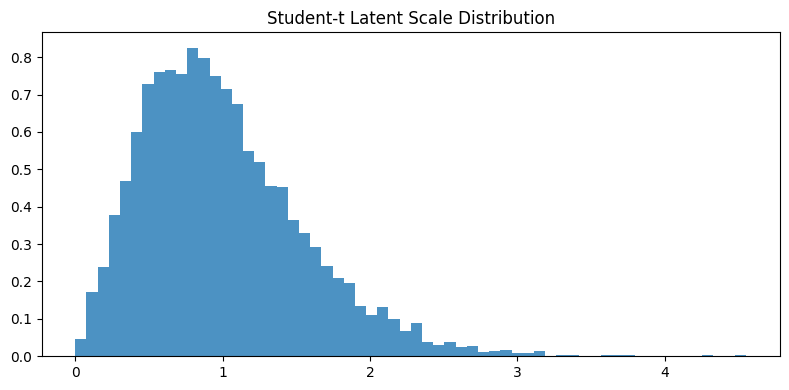

In [78]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lam_last, bins=60, density=True, alpha=0.8)
ax.set_title("Student-t Latent Scale Distribution")
plt.tight_layout()
savefig("student_t_lambda_histogram", T_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/student_t/student_t_residual_histograms_20260319_160726.png


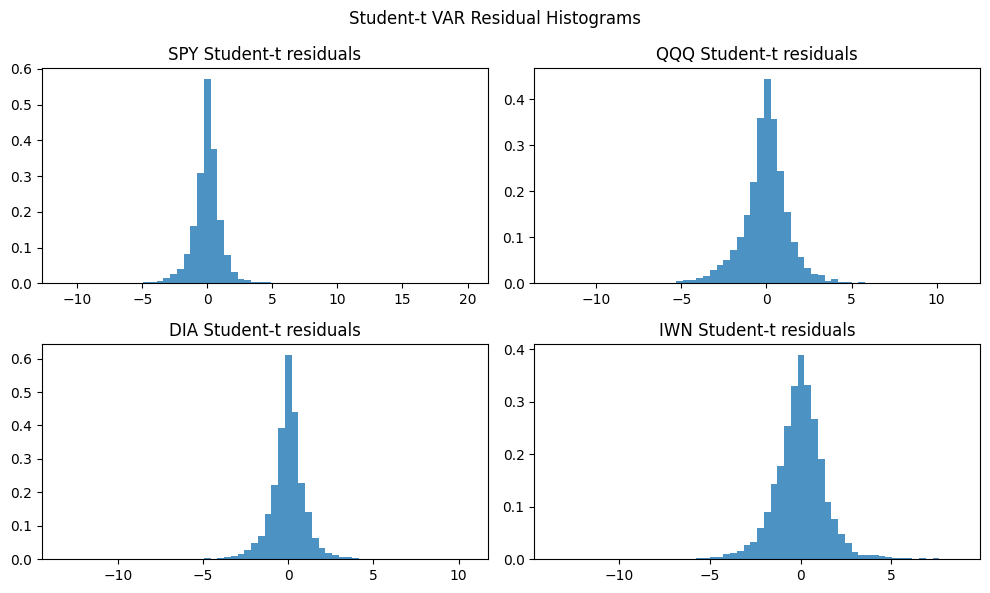

In [79]:
t_resid_df = pd.DataFrame(result_t.residuals_last, columns=SERIES)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()

for i, s in enumerate(SERIES):
    axes[i].hist(t_resid_df[s], bins=60, density=True, alpha=0.8)
    axes[i].set_title(f"{s} Student-t residuals")

plt.suptitle("Student-t VAR Residual Histograms")
plt.tight_layout()
savefig("student_t_residual_histograms", T_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/gaussian_mixture/mixture_regime_assignments_20260319_160726.png


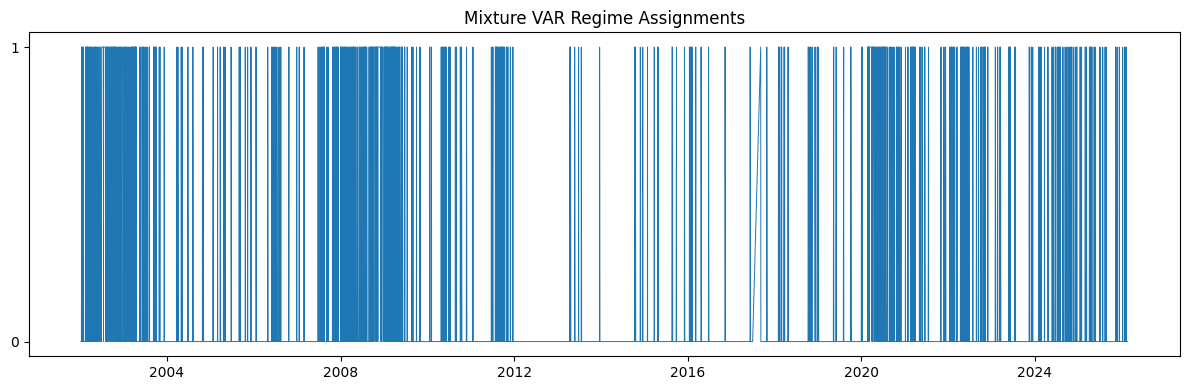

In [80]:
z_last = mix_result.z_draws[-1]
regime_df = pd.DataFrame({"date": mix_result.design.dates, "regime": z_last})

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(regime_df["date"], regime_df["regime"], linewidth=0.7)
ax.set_title("Mixture VAR Regime Assignments")
ax.set_yticks(sorted(regime_df["regime"].unique()))
plt.tight_layout()
savefig("mixture_regime_assignments", MIX_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/gaussian_mixture/mixture_regime_counts_20260319_160726.png


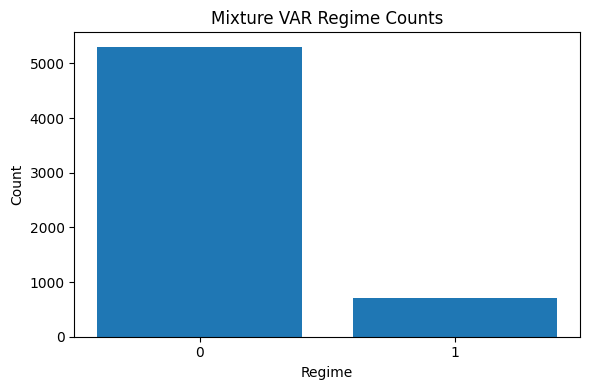

In [81]:
counts = pd.Series(z_last).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index.astype(str), counts.values)
ax.set_title("Mixture VAR Regime Counts")
ax.set_xlabel("Regime")
ax.set_ylabel("Count")
plt.tight_layout()
savefig("mixture_regime_counts", MIX_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/gaussian_mixture/mixture_posterior_regime_weights_20260319_160726.png


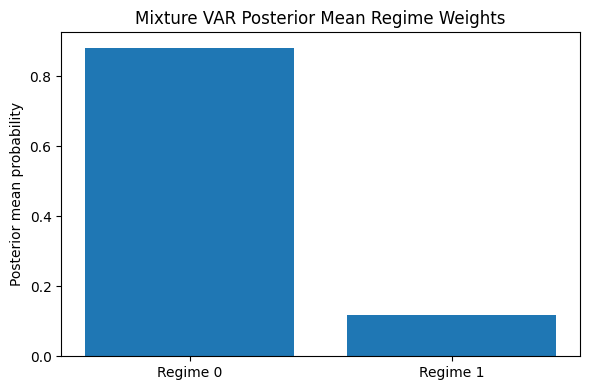

In [82]:
pi_mean = mix_model.posterior_mean_pi()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([f"Regime {i}" for i in range(len(pi_mean))], pi_mean)
ax.set_title("Mixture VAR Posterior Mean Regime Weights")
ax.set_ylabel("Posterior mean probability")
plt.tight_layout()
savefig("mixture_posterior_regime_weights", MIX_FIG)
plt.show()

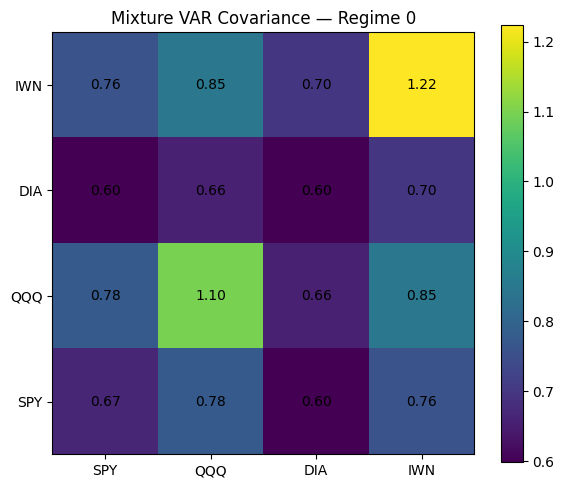

In [83]:
sigma_mix = mix_model.posterior_mean_sigma()
sigma0 = pd.DataFrame(sigma_mix[0], index=SERIES, columns=SERIES)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sigma0, aspect="equal", origin="lower")

ax.set_xticks(range(len(SERIES)))
ax.set_xticklabels(SERIES)

ax.set_yticks(range(len(SERIES)))
ax.set_yticklabels(SERIES)

ax.set_title("Mixture VAR Covariance — Regime 0")

for i in range(len(SERIES)):
    for j in range(len(SERIES)):
        ax.text(
            j, i,
            f"{sigma0.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()

plt.savefig(
    MIX_FIG / f"mixture_covariance_regime0_{RUN_TS}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

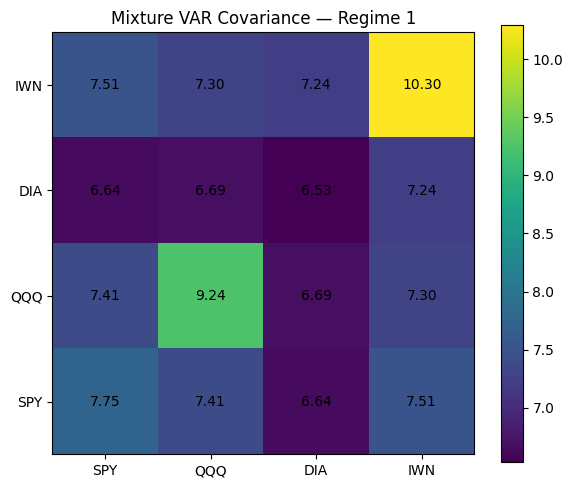

In [84]:
sigma1 = pd.DataFrame(sigma_mix[1], index=SERIES, columns=SERIES)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sigma1, aspect="equal", origin="lower")

ax.set_xticks(range(len(SERIES)))
ax.set_xticklabels(SERIES)

ax.set_yticks(range(len(SERIES)))
ax.set_yticklabels(SERIES)

ax.set_title("Mixture VAR Covariance — Regime 1")

for i in range(len(SERIES)):
    for j in range(len(SERIES)):
        ax.text(j, i, f"{sigma1.iloc[i, j]:.2f}",
                ha="center", va="center", color="black")

plt.colorbar(im, ax=ax)
plt.tight_layout()

plt.savefig(
    MIX_FIG / f"mixture_covariance_regime1_{RUN_TS}.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close()

Saved: outputs/figures/20260319_160726/sv/sv_latent_volatility_timeseries_20260319_160726.png


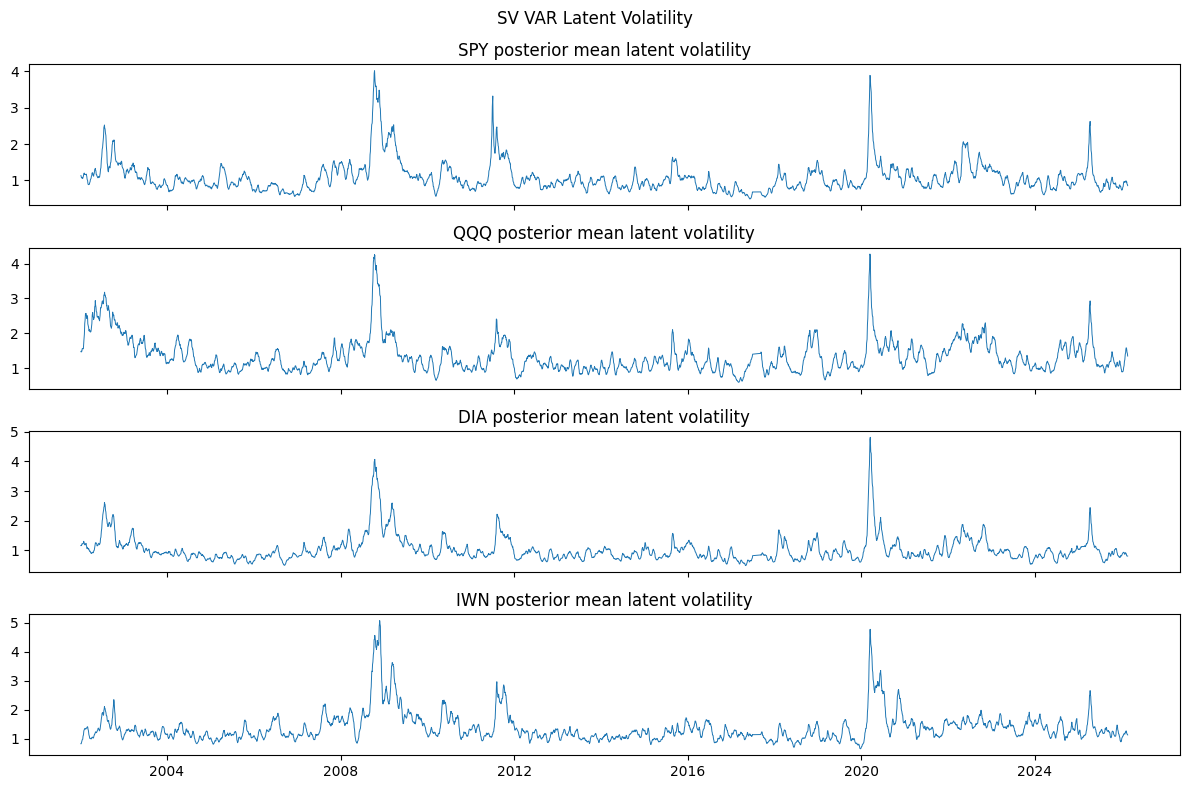

In [85]:
h_mean = sv_model.posterior_mean_h()

fig, axes = plt.subplots(len(SERIES), 1, figsize=(12, 8), sharex=True)

for i, s in enumerate(SERIES):
    axes[i].plot(sv_result.design.dates, np.exp(h_mean[:, i] / 2), linewidth=0.7)
    axes[i].set_title(f"{s} posterior mean latent volatility")

plt.suptitle("SV VAR Latent Volatility")
plt.tight_layout()
savefig("sv_latent_volatility_timeseries", SV_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/sv/sv_abs_return_vs_latent_vol_20260319_160726.png


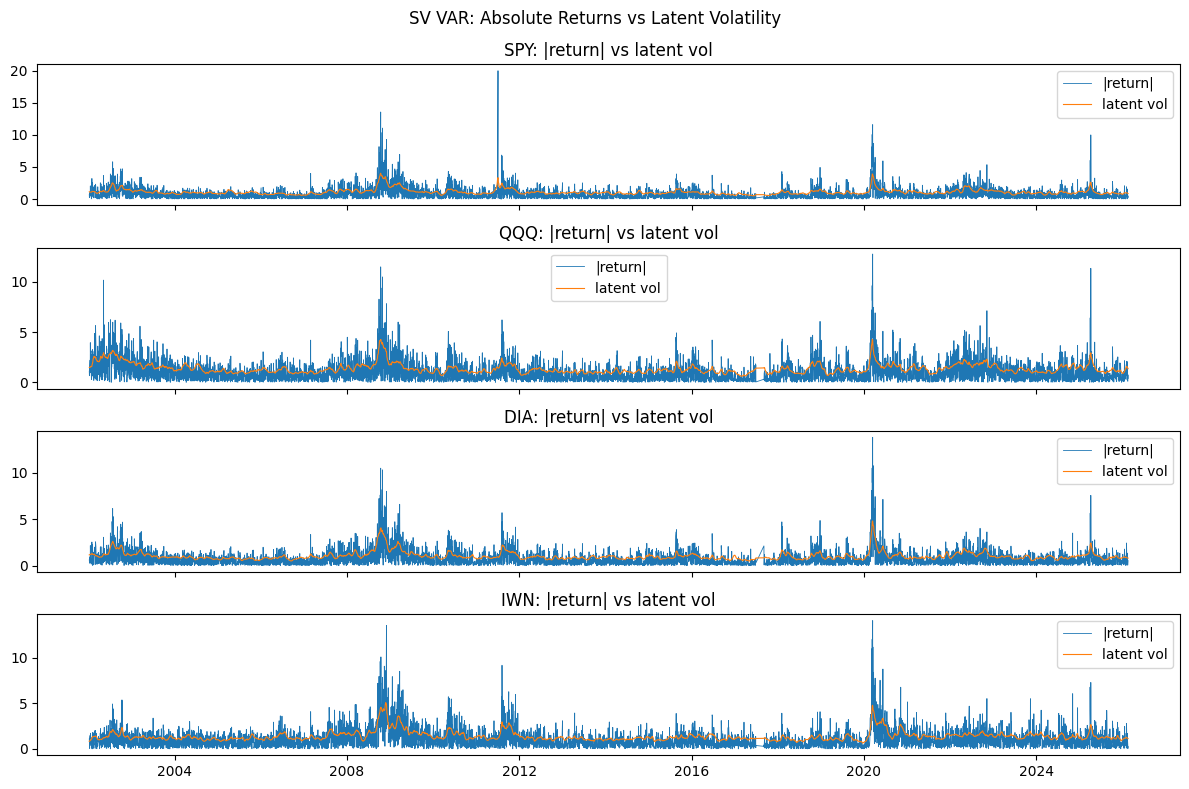

In [86]:
fig, axes = plt.subplots(len(SERIES), 1, figsize=(12, 8), sharex=True)

for i, s in enumerate(SERIES):
    axes[i].plot(df["date"].iloc[p:].reset_index(drop=True), np.abs(df[s].iloc[p:].to_numpy()), linewidth=0.6, label="|return|")
    axes[i].plot(sv_result.design.dates, np.exp(h_mean[:, i] / 2), linewidth=0.8, label="latent vol")
    axes[i].set_title(f"{s}: |return| vs latent vol")
    axes[i].legend()

plt.suptitle("SV VAR: Absolute Returns vs Latent Volatility")
plt.tight_layout()
savefig("sv_abs_return_vs_latent_vol", SV_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/common/predictive_density_comparison_spy_20260319_160726.png


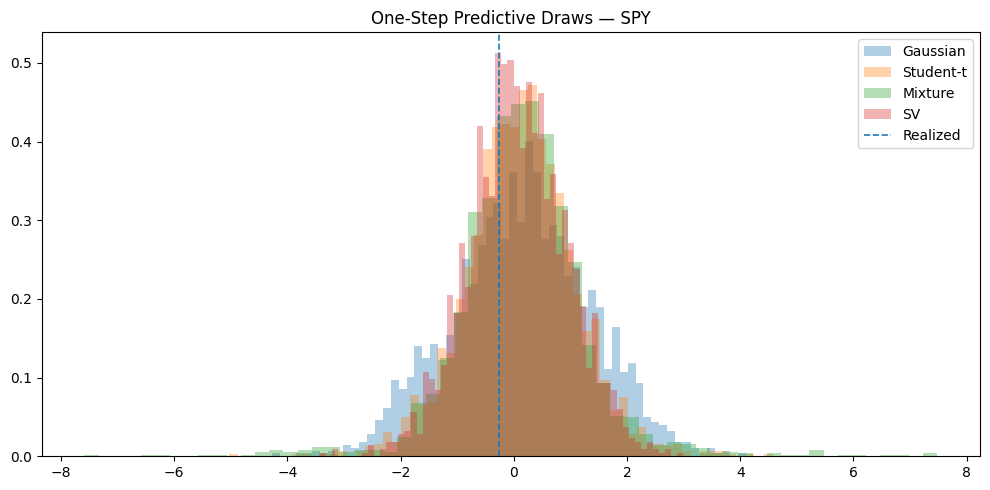

In [87]:
target = "SPY"
target_idx = SERIES.index(target)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(g_sims[:, target_idx], bins=60, density=True, alpha=0.35, label="Gaussian")
ax.hist(t_sims[:, target_idx], bins=60, density=True, alpha=0.35, label="Student-t")
ax.hist(mix_sims[:, target_idx], bins=60, density=True, alpha=0.35, label="Mixture")
ax.hist(sv_sims[:, target_idx], bins=60, density=True, alpha=0.35, label="SV")
ax.axvline(last_true[target_idx], linestyle="--", linewidth=1.2, label="Realized")
ax.set_title(f"One-Step Predictive Draws — {target}")
ax.legend()
plt.tight_layout()
savefig("predictive_density_comparison_spy", COMMON_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/common/rolling_mean_lps_comparison_20260319_160726.png


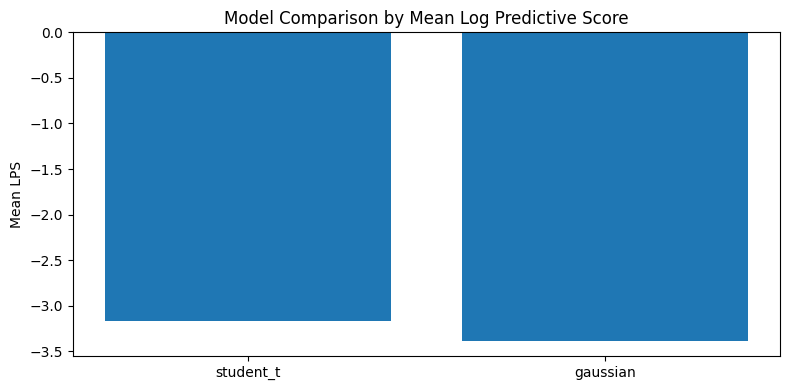

In [88]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary_df["model"], summary_df["mean_lps"])
ax.set_title("Model Comparison by Mean Log Predictive Score")
ax.set_ylabel("Mean LPS")
plt.tight_layout()
savefig("rolling_mean_lps_comparison", COMMON_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/common/rolling_var_hit_rate_comparison_20260319_160726.png


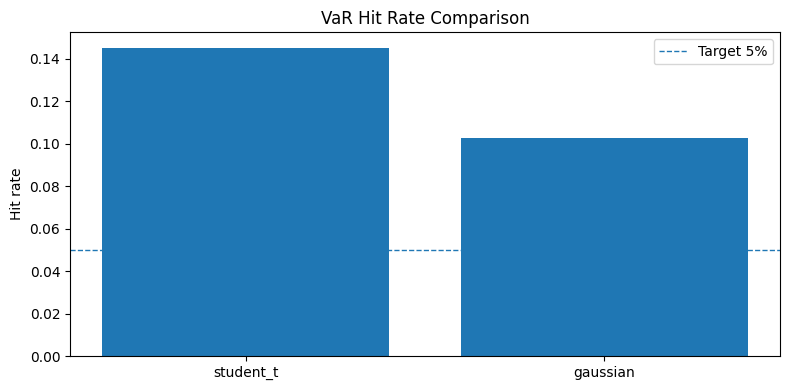

In [89]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(summary_df["model"], summary_df["var_hit_rate"])
ax.axhline(0.05, linestyle="--", linewidth=1.0, label="Target 5%")
ax.set_title("VaR Hit Rate Comparison")
ax.set_ylabel("Hit rate")
ax.legend()
plt.tight_layout()
savefig("rolling_var_hit_rate_comparison", COMMON_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/common/ess_comparison_20260319_160726.png


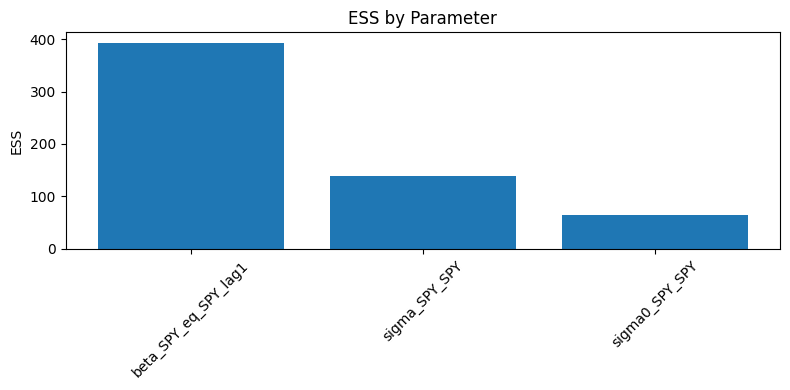

In [90]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(diag_df["parameter"], diag_df["ESS"])
ax.set_title("ESS by Parameter")
ax.set_ylabel("ESS")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
savefig("ess_comparison", COMMON_FIG)
plt.show()

Saved: outputs/figures/20260319_160726/common/chain_trace_comparison_20260319_160726.png


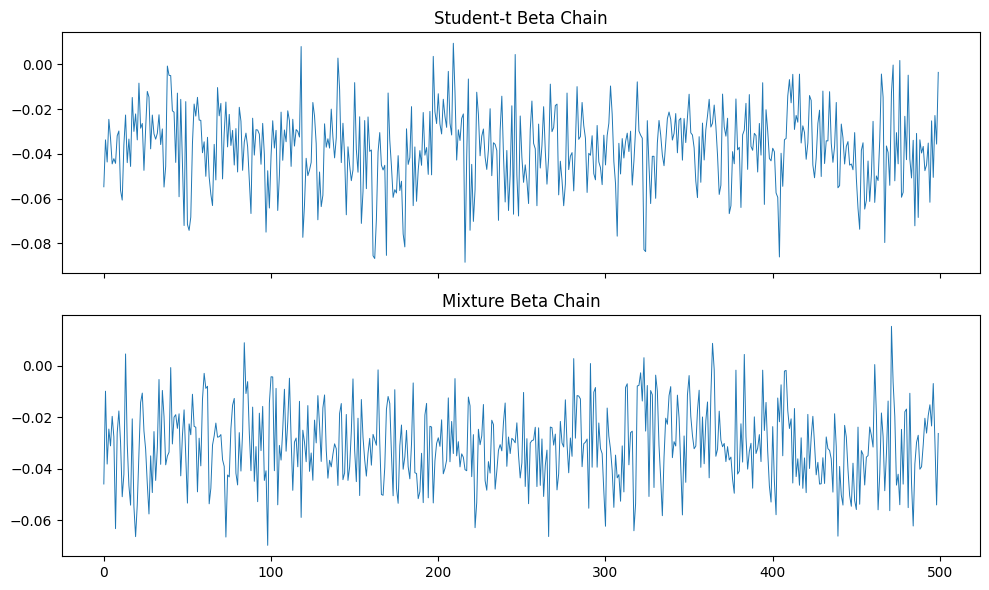

In [91]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(beta_chain_t, linewidth=0.7)
axes[0].set_title("Student-t Beta Chain")

axes[1].plot(beta_chain_mix, linewidth=0.7)
axes[1].set_title("Mixture Beta Chain")

plt.tight_layout()
savefig("chain_trace_comparison", COMMON_FIG)
plt.show()